In [5]:
from blockhouse_ml.utils import fetch_merge_data
import os

In [6]:
start_time = '2024-08-16'
end_time = '2024-08-16'
data_dir = "temp"
ticker = 'AEG'

os.makedirs(data_dir, exist_ok=True)

# filename = f'{data_dir}/merged_data_{ticker}_{start_time}_{end_time}.csv'
# if os.path.exists(filename):
#     data = pd.read_csv(filename)
# else:
data = fetch_merge_data.fetch_and_merge_data(ticker,start_date=start_time,end_date=end_time,save_dir =data_dir,limit=50000)

Merged data saved to merged_data_AEG_2024-08-16_2024-08-16.csv


c:\Users\yashv\Documents\Companies\blockhouse\Model-Development\RL Model Helper\Models\utils\fetch_merge_data.py:119: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  quotes = df.resample('min').agg({


In [7]:
data.describe()

,timestamp,open,high,low,close,volume,ask_price,ask_size,bid_price,bid_size
count,2.490000e+02,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,1.723823e+12,6.373325,6.375480,6.371299,6.373486,6272.646586,6.378675,3504.273092,6.368715,5519.907631
std,5.377321e+06,0.023793,0.023984,0.023651,0.023985,14463.436147,0.024762,5513.181105,0.024674,11993.151181
min,1.723801e+12,6.320000,6.320000,6.320000,6.320000,100.000000,6.320000,0.000000,6.320000,0.000000
25%,1.723819e+12,6.355000,6.355000,6.350000,6.355000,301.000000,6.360000,0.000000,6.350000,0.000000
50%,1.723823e+12,6.365000,6.370000,6.365000,6.365000,769.000000,6.370000,1349.000000,6.360000,1440.000000
75%,1.723828e+12,6.400000,6.400000,6.400000,6.400000,5335.000000,6.410000,4799.000000,6.400000,4500.000000
max,1.723832e+12,6.410000,6.410000,6.410000,6.410000,146444.000000,6.410000,31771.000000,6.400000,106314.000000


In [ ]:
from blockhouse_ml.utils.data_handler import DataProcessor
data_processor = DataProcessor()
forecast_steps = {
            'open': (360, '1T'),
            'high': (360, '1T'),
            'low': (360, '1T'),
            'close': (360, '1T'),
            'volatility': (360, '1T'),
            'volume': (360, '1T'),
            'transaction_cost': (360, '1T')
        }

In [ ]:
data = data_processor.process_data(data, forecast_steps)
data.to_csv('processed_data.csv')

In [ ]:

data

In [42]:
from blockhouse_ml.utils.data_handler import InferenceDataHandler, DataProcessor
from blockhouse_ml.utils import fetch_merge_data
import os
import pandas as pd

In [43]:
ticker = 'AAPL'

data_dir = "Data"

start_time = '2024-07-01'
end_time = '2024-08-16'

market_cap_int = fetch_merge_data.get_market_cap(ticker)

data_processor = DataProcessor()

filename = f'{data_dir}/merged_data_{ticker}_{start_time}_{end_time}.csv'
if os.path.exists(filename):
    data = pd.read_csv(filename)
else:
    data = fetch_merge_data.fetch_and_merge_data(ticker,start_date=start_time,end_date=end_time,save_dir =data_dir)

# For inference we will technical indicators only
processed_data = data_processor.add_technical_indicators(data)
# processed_data.to_csv(processed_filename)
train_data = processed_data[:int(len(processed_data) * 0.8)]
test_data = processed_data[int(len(processed_data) * 0.8):]

c:\Users\yashv\Documents\Companies\blockhouse\Model-Development\RL Model Helper\Models\utils\data_handler.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['transaction_cost'] = self.data.apply(almgren, axis=1)
c:\Users\yashv\Documents\Companies\blockhouse\Model-Development\RL Model Helper\Models\utils\data_handler.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['5_min_volatility'] = self.data['volatility'].transform(lambda x: x.rolling(window=5).std())
c:\Users\yashv\Documents

In [48]:
print(len(train_data))
sub_data = train_data[train_data['ask_size']==0]
print(len(sub_data))

sub_data['volume']

20711
14638


40          905.0
41         3783.0
42          556.0
43          516.0
44          926.0
           ...   
20746     56842.0
20747     88907.0
20748     69609.0
20749    123362.0
20750     90497.0
Name: volume, Length: 14638, dtype: float64

In [19]:
test_data['datetime']

20751    2024-08-07 19:48:00
20752    2024-08-07 19:49:00
20753    2024-08-07 19:50:00
20754    2024-08-07 19:51:00
20755    2024-08-07 19:52:00
                ...         
25924    2024-08-16 19:50:00
25925    2024-08-16 19:51:00
25926    2024-08-16 19:52:00
25927    2024-08-16 19:53:00
25928    2024-08-16 19:54:00
Name: datetime, Length: 5178, dtype: object

In [22]:
preferred_timeframe=500
inventory=10000
twap_shares_per_step = inventory / preferred_timeframe

count    7.900000e+02
mean     5.316055e+04
std      1.401672e+05
min      1.050000e+02
25%      1.288500e+03
50%      2.571050e+04
75%      7.215600e+04
max      2.392549e+06
Name: volume, dtype: float64


C:\Users\yashv\AppData\Local\Temp\ipykernel_1600\29115306.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['step_vise_vol'] = [(filtered_df.iloc[i]['volume']/filtered_df.volume.sum())*inventory for i in range(len(filtered_df))]
C:\Users\yashv\AppData\Local\Temp\ipykernel_1600\29115306.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['step_vise_twap'] = [twap_shares_per_step for i in range(len(filtered_df))]


<Axes: xlabel='datetime'>

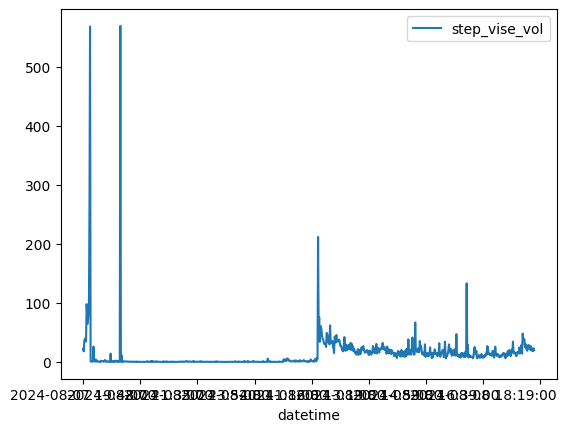

In [25]:
df = test_data [['volume','timestamp','datetime']].copy()
filtered_df = df.loc[(df['datetime'] >= '2024-08-07 19:48:00') & (df['datetime'] <= '2024-08-08 19:48:00')]
filtered_df['step_vise_vol'] = [(filtered_df.iloc[i]['volume']/filtered_df.volume.sum())*inventory for i in range(len(filtered_df))]
filtered_df['step_vise_twap'] = [twap_shares_per_step for i in range(len(filtered_df))]
print(filtered_df['volume'].describe())
filtered_df.plot(x='datetime', y='step_vise_vol')

<Axes: xlabel='datetime'>

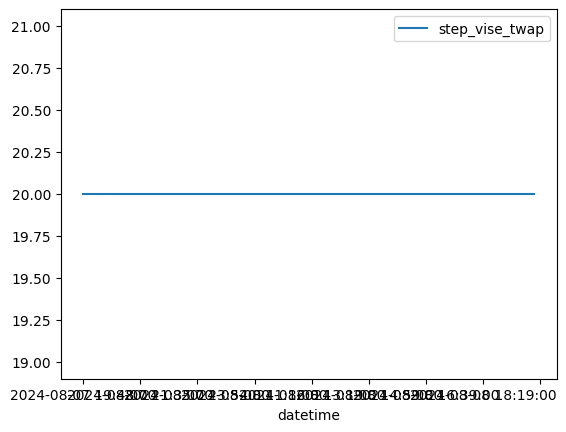

In [26]:
filtered_df.plot(x='datetime', y='step_vise_twap')

In [5]:

timeframe=500
inventory=10000
inference_data.add_real_time_forecasts(test_data,1, "micro")

LOGGING: Adding Real-Time Forecasts to data...


c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yashv\miniconda3\envs\ML

         open        high         low       close         volume  volatility  \
0  225.894592  225.937489  225.756021  225.813308  108577.229194    0.000524   

   transaction_cost        RSI      MACD  MACD_signal  ...  5_min_TC  \
0          0.246486  47.012147 -0.066929    -0.077035  ...  0.204179   

   expected_price  timestamp  forecast_6Hr_open  forecast_6Hr_high  \
0        226.1268      25928         225.139785         225.033667   

   forecast_6Hr_low  forecast_6Hr_close  forecast_6Hr_volume  \
0        224.323469          224.417247        208434.979596   

   forecast_6Hr_volatility  forecast_6Hr_transaction_cost  
0                 0.000432                       0.241205  

[1 rows x 34 columns]


c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\yashv\miniconda3\envs\MLProj\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c

,open,high,low,close,volume,volatility,transaction_cost,RSI,MACD,MACD_signal,...,5_min_TC,expected_price,timestamp,forecast_6Hr_open,forecast_6Hr_high,forecast_6Hr_low,forecast_6Hr_close,forecast_6Hr_volume,forecast_6Hr_volatility,forecast_6Hr_transaction_cost
0,225.894592,225.937489,225.756021,225.813308,108577.229194,0.000524,0.246486,47.012147,-0.066929,-0.077035,...,0.204179,226.1268,25928,225.139785,225.033667,224.323469,224.417247,208434.979596,0.000432,0.241205


In [14]:
input_row

,Unnamed: 0,timestamp,datetime,open,high,low,close,volume,ask_price,ask_size,...,5_min_volatility,5_min_volume,5_min_TC,forecast_6Hr_open,forecast_6Hr_high,forecast_6Hr_low,forecast_6Hr_close,forecast_6Hr_volatility,forecast_6Hr_volume,forecast_6Hr_transaction_cost
0,25928,1723838040000,2024-08-16 19:54:00,225.91,225.94,225.76,225.81,146362.0,226.13,0,...,0.000155,644985.0,0.205744,225.141881,225.036178,224.327449,224.421125,0.002044,208057.727457,0.341975


In [15]:
test_data.iloc[-1]

Unnamed: 0                        25928
timestamp                 1723838040000
datetime            2024-08-16 19:54:00
open                             225.91
high                             225.94
low                              225.76
close                            225.81
volume                         146362.0
ask_price                        226.13
ask_size                              0
bid_price                        226.12
bid_size                              0
RSI                           46.736262
MACD                          -0.075015
MACD_signal                   -0.077708
MACD_hist                      0.002693
Stoch_k                       43.174863
Stoch_d                       36.198239
OBV                          48142745.0
Upper_BB                     226.189155
Middle_BB                    225.876125
Lower_BB                     225.563095
ATR_1                              0.18
ATR_2                          0.204662
ATR_5                          0.193686


In [21]:
input_row['expected_price']

0    226.12
Name: expected_price, dtype: object

In [29]:
import numpy as np
import pandas as pd

In [36]:
data = test_data.copy()
total_volume = data['volume'].sum()
total_steps = len(data)
initial_inventory = inventory
remaining_inventory = initial_inventory

# vwap_rewards will have a list of lists, where each list will have reward components
vwap_rewards = []
slippage = []
market_impact = []
liquidity_penalty = []
tc = []

alpha = 4.439584265535017e-06
lambda_ = 0.05
# count = 0
for step in range(min(total_steps, preferred_timeframe)):
    volume_at_step = data['volume'].iloc[step]
    
    # Calculate the number of shares to trade based on the VWAP formula
    size_of_slice = (volume_at_step / total_volume) * initial_inventory
    size_of_slice = min(size_of_slice, remaining_inventory)
    # print(f"Size of slice: {size_of_slice}")
    remaining_inventory -= int(np.ceil(size_of_slice))
    Market_Impact = alpha * np.sqrt(size_of_slice)
    print("size of slice: ", size_of_slice, " | price : ",data.iloc[step]['close'], " | Market Impact: ", Market_Impact)
    # reward = compute_components(data.iloc[step], alpha, lambda_, size_of_slice)
    # print(f"Slippage: {reward[0]}")
    # slippage.append(reward[0])
    # market_impact.append(reward[1])
    # liquidity_penalty.append(reward[2])
    # tc.append(reward[3])
    
    # vwap_rewards.append(reward)
    
    if remaining_inventory <= 0:
        break
print("Total steps: ", step)


size of slice:  3.633089300765484  | price :  210.51  | Market Impact:  8.462142607615293e-06
size of slice:  2.973010989459043  | price :  210.6697  | Market Impact:  7.654918316051368e-06
size of slice:  6.030151537540352  | price :  210.42  | Market Impact:  1.0902005996571795e-05
size of slice:  6.46576619969497  | price :  210.34  | Market Impact:  1.1288917568136237e-05
size of slice:  6.159102930297514  | price :  210.3264  | Market Impact:  1.1017956021655397e-05
size of slice:  5.735658695864938  | price :  210.51  | Market Impact:  1.0632464803631052e-05
size of slice:  16.209591811849663  | price :  210.0  | Market Impact:  1.787427119174846e-05
size of slice:  13.201566226128824  | price :  209.74  | Market Impact:  1.6130767549127626e-05
size of slice:  10.672165357813311  | price :  209.78  | Market Impact:  1.4503358306756101e-05
size of slice:  12.875249094487684  | price :  209.72  | Market Impact:  1.593015947608243e-05
size of slice:  15.284678691472005  | price :  2

In [41]:
data = test_data.copy()
total_steps = len(data)
twap_shares_per_step = initial_inventory / preferred_timeframe
remaining_inventory = initial_inventory

# twap_rewards will have a list of lists, where each list will have reward components
twap_rewards = []
slippage = []
market_impact = []
liquidity_penalty = []
tc = []
slippages = []
shares_traded = []

alpha = 4.439584265535017e-06
lambda_ = 0.05


for step in range(min(total_steps, preferred_timeframe)):
    # print(f"Step:{step} / {min(total_steps, preferred_timeframe)}")
    size_of_slice = min(twap_shares_per_step, remaining_inventory)
    remaining_inventory -= int(np.ceil(size_of_slice))
    Market_Impact = alpha * np.sqrt(size_of_slice)
    slippages.append(data.iloc[step]['expected_price'] - data.iloc[step]['close'])
    shares_traded.append(size_of_slice)
    # print("size of slice: ", size_of_slice, " | price : ",data.iloc[step]['close'], " | Market Impact: ", Market_Impact)
    if remaining_inventory <= 0:
        break
slip_arr = np.vstack(slippages)
share_arr = np.vstack(shares_traded)

rew_arr = slip_arr * share_arr
rew_mean = rew_arr.mean()
rew_std = rew_arr.std()
# print("Slip arr : ", slip_arr)
# print("Share arr : ", share_arr)
# print("Rew arr : ", rew_arr)
print(np.concatenate((slip_arr, share_arr, rew_arr), axis=1))
# print("slippage on OUR: ", rew_mean)

# print("Total steps: ", step)

[[ -1.58    20.     -31.6   ]
 [ -1.7397  20.     -34.794 ]
 [ -1.49    20.     -29.8   ]
 ...
 [ -1.42    20.     -28.4   ]
 [ -1.54    20.     -30.8   ]
 [ -1.37    20.     -27.4   ]]
